In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
  Using cached cartopy-0.25.0-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached pyshp-3.0.3-py3-none-any.whl.metadata (65 kB)
  Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl.metadata (31 kB)
Using cached cartopy-0.25.0-cp313-cp313-win_amd64.whl (11.0 MB)
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
ds = xr.open_dataset("cru_ts4.07.1901.2022.pre.dat.nc.gz")
ds

<xarray.Dataset> Size: 5GB
Dimensions:  (lon: 720, lat: 360, time: 1464)
Coordinates:
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2022-12-16
Data variables:
    pre      (time, lat, lon) float32 2GB ...
    stn      (time, lat, lon) float64 3GB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [4]:
lat_min = 12
lat_max = 19
lon_min = 42
lon_max = 55

In [6]:
ds = ds.sel(time=slice("1990-01-01", "2020-12-31"))

# Subset Yemen
yemen = ds.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)
yemen

<xarray.Dataset> Size: 2MB
Dimensions:  (lon: 26, lat: 14, time: 372)
Coordinates:
  * lon      (lon) float32 104B 42.25 42.75 43.25 43.75 ... 53.75 54.25 54.75
  * lat      (lat) float32 56B 12.25 12.75 13.25 13.75 ... 17.75 18.25 18.75
  * time     (time) datetime64[ns] 3kB 1990-01-16 1990-02-15 ... 2020-12-16
Data variables:
    pre      (time, lat, lon) float32 542kB ...
    stn      (time, lat, lon) float64 1MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [8]:
mean_pre = yemen['pre'].mean(dim='time')
mean_pre

<xarray.DataArray 'pre' (lat: 14, lon: 26)> Size: 1kB
array([[16.224457 , 20.096237 ,  9.916664 ,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,  5.8333335,        nan,        nan,
        12.75     ,        nan, 19.583334 , 19.241682 , 19.791666 ,
               nan],
       [15.381989 ,  8.239246 ,  6.3295693,  9.407522 , 10.47231  ,
         6.675807 ,  4.64865  ,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan, 16.541677 , 17.77498  , 21.175005 ,
               nan],
       [ 9.183599 ,  6.1400585,  7.2994647, 22.460772 , 34.059658 ,
        17.138166 , 10.115606 ,  9.205655 ,  4.69381  ,  3.4663992,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan],
       [ 6.841669 ,  7.2862883,  7.935761 , 29.006708 , 44.73443  ,
        38.04782  , 33.319077 , 25.373932 , 15.547056 ,  7.326341 ,
...
         6.535214 ,  5.865321 ,  5.691664 ,  6.02258  ,  5.7204294,
         8.603502 ],
       [ 7.1868258, 11.891664 , 21.762892 , 24.148136 , 17.013712 ,
        13.696755 , 12.304826 , 11.105909 ,  9.976333 ,  9.010745 ,
         8.414251 ,  7.75807  ,  6.6397824,  5.8919387,  5.3217716,
         5.0666666,  5.2806425,  5.730106 ,  5.3655915,  4.7814536,
         4.3677406,  3.5451584,  2.8104815,  2.1647847,  2.5551057,
         4.1424694],
       [14.598406 , 21.6081   , 23.547567 , 21.336008 , 15.642459 ,
        12.309402 , 11.3102045, 10.357804 ,  9.167753 ,  8.136013 ,
         7.1174703,  6.4876304,  5.817475 ,  5.1150513,  4.6397786,
         4.268012 ,  3.9279566,  4.053763 ,  3.6005414,  3.2193522,
         2.9126358,  2.418278 ,  1.9647822,  1.7475798,  1.9833341,
         2.673386 ],
       [17.625282 , 18.383091 , 17.365063 , 16.080645 , 13.497038 ,
        11.138437 , 10.322853 ,  9.37312  ,  8.678759 ,  7.7247267,
         6.744357 ,  5.9099517,  5.3053713,  4.731453 ,  4.335217 ,
         3.9852128,  3.454032 ,  3.3561847,  2.9889789,  2.6220438,
         2.3478472,  2.0260758,  1.813173 ,  1.7247298,  1.8715037,
         2.3543007]], dtype=float32)
Coordinates:
  * lon      (lon) float32 104B 42.25 42.75 43.25 43.75 ... 53.75 54.25 54.75
  * lat      (lat) float32 56B 12.25 12.75 13.25 13.75 ... 17.75 18.25 18.75

MONTHLY MEAN PRECIPITATION

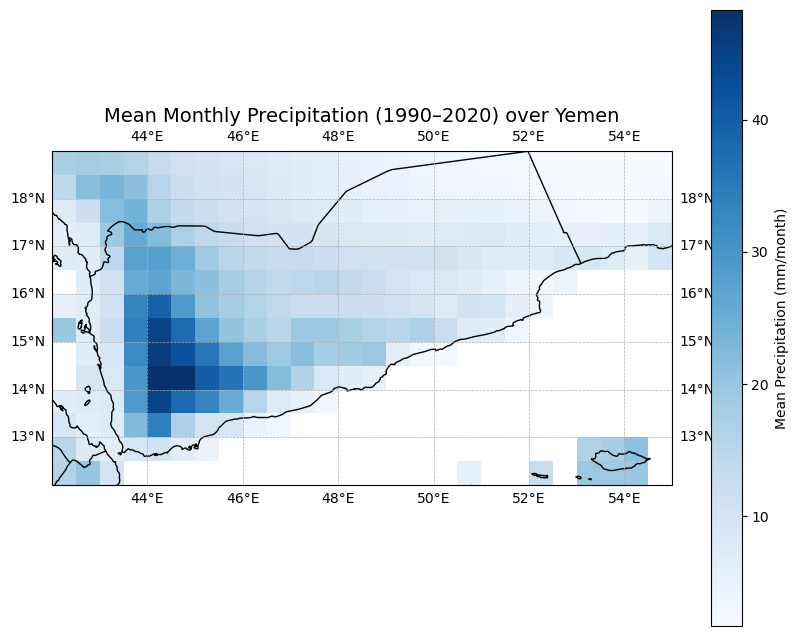

In [10]:
# 4. Plot map for monthly mean precipitation
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Plot precipitation
mean_pre.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={
        'label': 'Mean Precipitation (mm/month)'
})
# geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=1)

ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.top_labels = False
ax.right_labels = False

ax.set_title("Mean Monthly Precipitation (1990–2020) over Yemen", fontsize=14)

plt.show()

ANNUAL TOTAL AMOUNT OF PRECIPITATION

In [12]:
annual_total = nigeria['pre'].resample(time='Y').sum()
annual_total

C:\Users\Dell\anaconda3\Lib\site-packages\xarray\groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'pre' (time: 31, lat: 14, lon: 26)> Size: 45kB
array([[[133.90002 , 152.4     ,  69.2     , ..., 230.9     ,
         237.5     ,   0.      ],
        [122.8     ,  63.9     ,  45.4     , ..., 213.3     ,
         254.09999 ,   0.      ],
        [ 77.899994,  53.500004,  50.5     , ...,   0.      ,
           0.      ,   0.      ],
        ...,
        [ 85.4     , 142.70003 , 264.8     , ...,  24.2     ,
          29.300003,  47.400005],
        [175.09999 , 260.7     , 285.1     , ...,  20.      ,
          23.      ,  31.400002],
        [211.40001 , 220.6     , 208.60002 , ...,  19.5     ,
          21.800001,  27.7     ]],

       [[152.3     , 167.69998 ,  85.299995, ..., 230.9     ,
         237.5     ,   0.      ],
        [143.7     ,  74.9     ,  54.7     , ..., 213.3     ,
         254.09999 ,   0.      ],
        [ 92.60001 ,  62.3     ,  54.600006, ...,   0.      ,
           0.      ,   0.      ],
...
        [ 86.2     , 142.70001 , 261.2     , ...,  10.      ,
          12.400001,  21.800001],
        [175.20001 , 259.30002 , 282.6     , ...,   8.500001,
          10.100001,  15.099999],
        [211.5     , 220.60002 , 208.40001 , ...,  10.2     ,
          11.400001,  15.700001]],

       [[194.4     , 239.2     , 114.90001 , ..., 230.9     ,
         237.5     ,   0.      ],
        [183.20001 ,  95.700005,  72.4     , ..., 213.3     ,
         254.09999 ,   0.      ],
        [108.20001 ,  71.1     ,  83.      , ...,   0.      ,
           0.      ,   0.      ],
        ...,
        [ 86.2     , 142.70001 , 261.2     , ...,  18.3     ,
          21.9     ,  37.600002],
        [175.20001 , 259.30002 , 282.6     , ...,  14.599999,
          17.      ,  24.600002],
        [211.5     , 220.60002 , 208.40001 , ...,  15.400001,
          16.800001,  22.300001]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 104B 42.25 42.75 43.25 43.75 ... 53.75 54.25 54.75
  * lat      (lat) float32 56B 12.25 12.75 13.25 13.75 ... 17.75 18.25 18.75
  * time     (time) datetime64[ns] 248B 1990-12-31 1991-12-31 ... 2020-12-31
Attributes:
    long_name:                   precipitation
    units:                       mm/month
    correlation_decay_distance:  450.0

In [13]:
annual_mean_series = annual_total.mean(dim=['lat', 'lon'])

In [14]:
years = annual_mean_series['time'].dt.year
precip_values = annual_mean_series.values

PLOT OF ANNUAL TOTAL PRECIPITATION

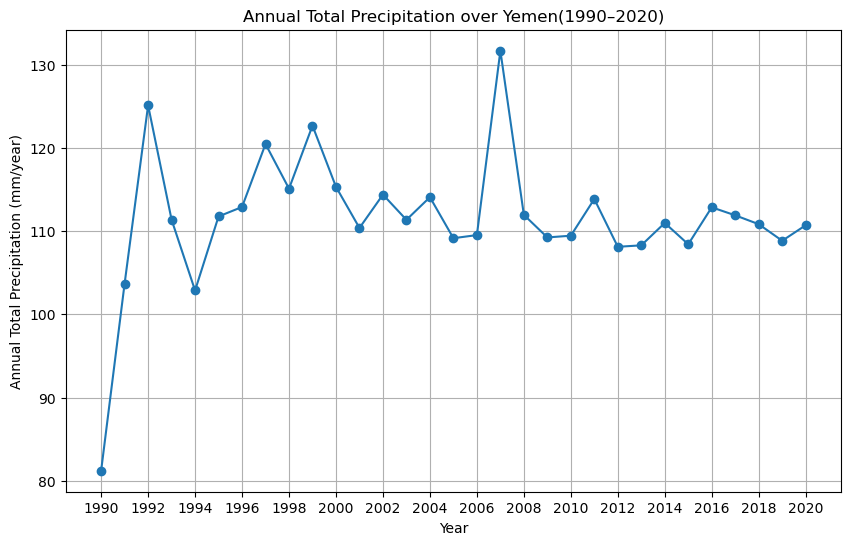

In [15]:
plt.figure(figsize=(10,6))

plt.plot(years, precip_values, marker='o')

plt.xticks(np.arange(years.min(), years.max()+1, 2))
plt.xlabel("Year")
plt.ylabel("Annual Total Precipitation (mm/year)")
plt.title("Annual Total Precipitation over Yemen(1990–2020)")
plt.grid(True)

plt.show()


In [16]:
coefficients = np.polyfit(years, precip_values, 1)

slope = coefficients[0]
intercept = coefficients[1]

trend_line = slope * years + intercept


TREND IN ANNUAL TOTAL PRECIPITATION

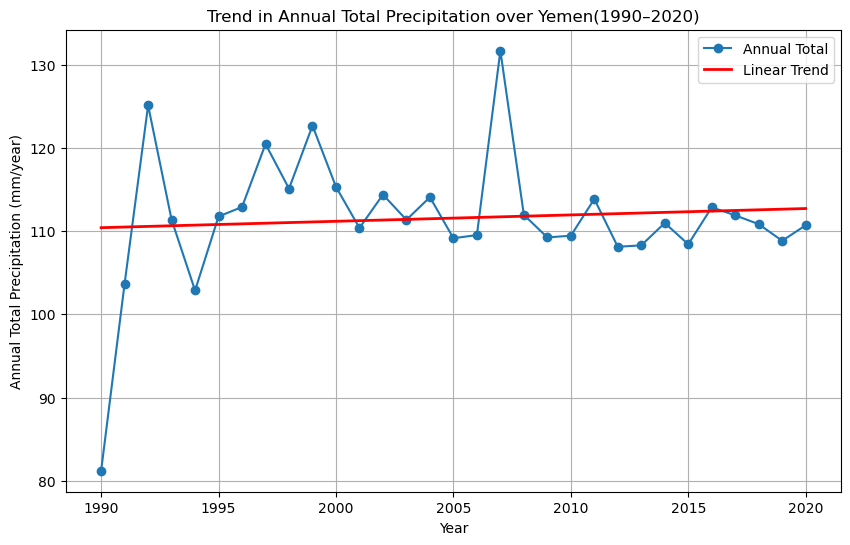

In [17]:
plt.figure(figsize=(10,6))

plt.plot(years, precip_values, marker='o', label='Annual Total')
plt.plot(years, trend_line, color='red', linewidth=2, label='Linear Trend')

plt.xlabel("Year")
plt.ylabel("Annual Total Precipitation (mm/year)")
plt.title("Trend in Annual Total Precipitation over Yemen(1990–2020)")
plt.legend()
plt.grid(True)

plt.show()


In [18]:
print("Slope (mm/year per year):", slope)
print("Trend per decade (mm/year):", slope * 10)


Slope (mm/year per year): 0.07663065387355279
Trend per decade (mm/year): 0.7663065387355279


In [19]:
std_dev = annual_mean_series.std()
print("Standard Deviation (mm/year):", std_dev.values)


Standard Deviation (mm/year): 7.954158782958984


In [20]:
annual_total = yemen['pre'].resample(time='Y').sum()


C:\Users\Dell\anaconda3\Lib\site-packages\xarray\groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


In [21]:
decade1 = annual_total.sel(time=slice("1990", "1999")).mean(dim='time')
decade2 = annual_total.sel(time=slice("2010", "2020")).mean(dim='time')


MEAN ANUUAL PRECIP FOR 1990-1999 PLOT

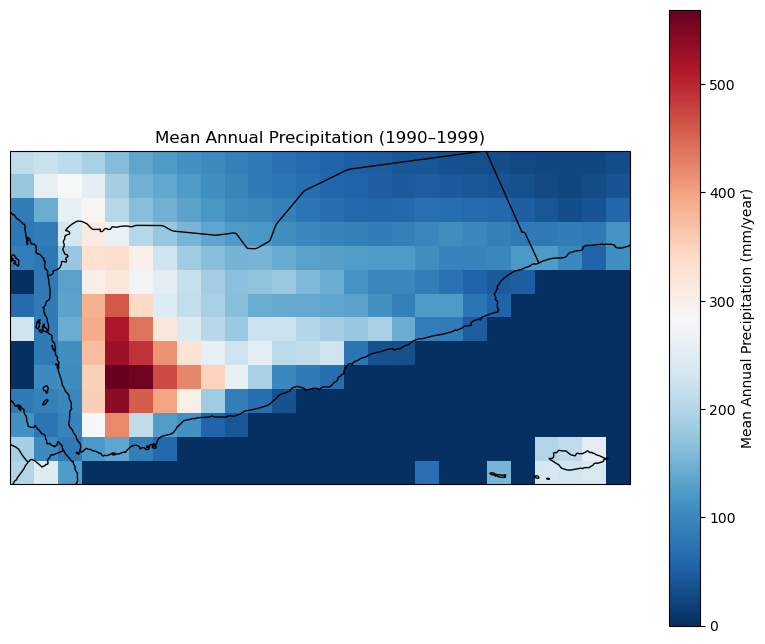

In [22]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

decade1.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    cbar_kwargs={'label': 'Mean Annual Precipitation (mm/year)'}
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_title("Mean Annual Precipitation (1990–1999)")

plt.show()


MEAN ANNUAL PRECIP FOR 2010-2020 PL0T

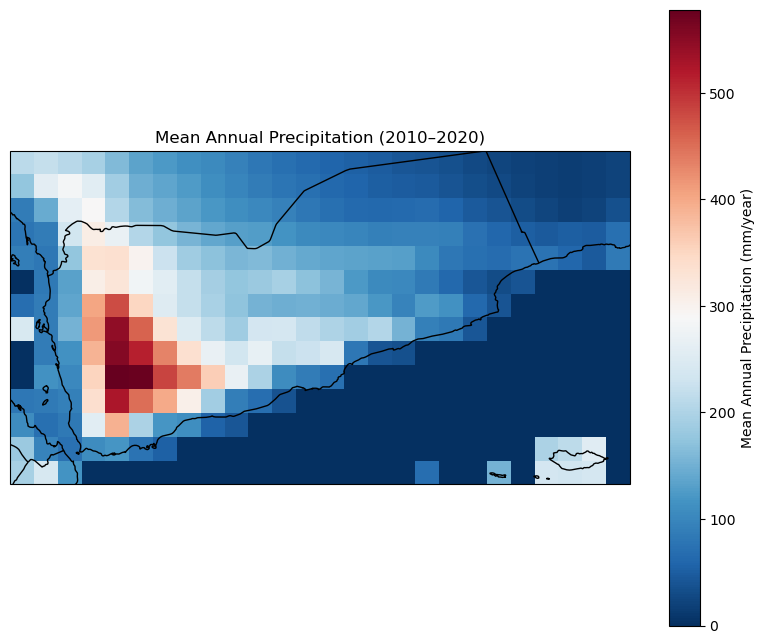

In [23]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

decade2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    cbar_kwargs={'label': 'Mean Annual Precipitation (mm/year)'})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_title("Mean Annual Precipitation (2010–2020)")

plt.show()


In [24]:
difference = decade2 - decade1


CHANGE IN ANNUAL MEAN PRECIPITATION OVER YEMEN (2010-2020 minus 1990-1999)

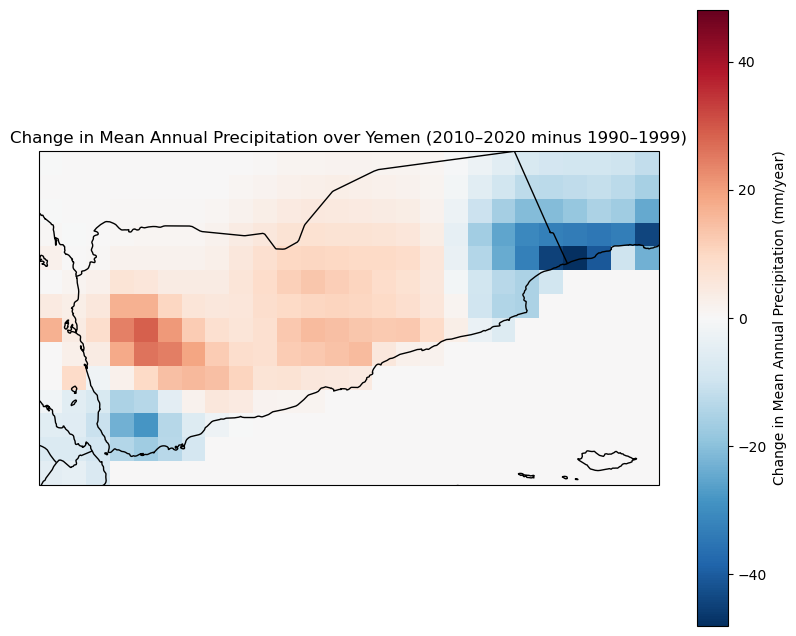

In [26]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

difference.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    cbar_kwargs={'label': 'Change in Mean Annual Precipitation (mm/year)'}
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_title("Change in Mean Annual Precipitation over Yemen (2010–2020 minus 1990–1999)")

plt.show()


In [27]:
diff_flat = difference.stack(points=("lat", "lon"))

In [28]:
top_increase = diff_flat.sortby(diff_flat, ascending=False).isel(points=slice(0,5))


In [29]:
top_decrease = diff_flat.sortby(diff_flat).isel(points=slice(0,5))

In [30]:
increase_table = top_increase.reset_index("points").to_dataframe(name="Change_mm_per_year")
decrease_table = top_decrease.reset_index("points").to_dataframe(name="Change_mm_per_year")

print("Top 5 Increases")
print(increase_table)

print("\nTop 5 Decreases")
print(decrease_table)


Top 5 Increases
          lat    lon  Change_mm_per_year
points                                  
0       15.25  44.25           28.789978
1       14.75  44.25           25.950012
2       14.75  44.75           24.489929
3       15.25  43.75           24.399994
4       15.25  44.75           20.869965

Top 5 Decreases
          lat    lon  Change_mm_per_year
points                                  
0       16.75  53.25          -48.116364
1       16.75  52.75          -44.789085
2       17.25  54.75          -44.188179
3       16.75  53.75          -40.867271
4       17.25  53.75          -34.718178


90th PERCENTILE

In [31]:
annual_total = nigeria['pre'].resample(time='Y').sum()

C:\Users\Dell\anaconda3\Lib\site-packages\xarray\groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


In [32]:
p90 = annual_total.quantile(0.9, dim='time')

In [33]:
wet_years = annual_total > p90
wet_frequency = wet_years.sum(dim='time')

90th PERCENTILE PLOT

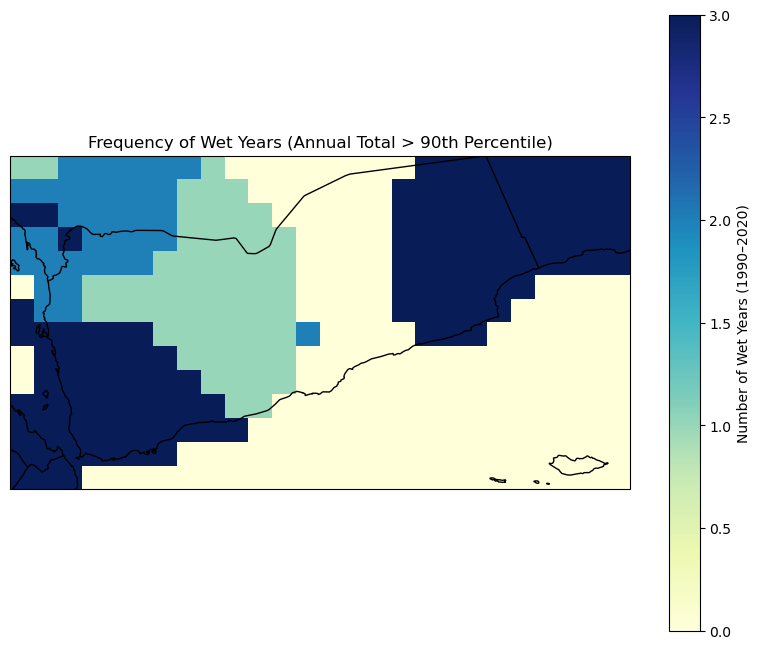

In [34]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

wet_frequency.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    cbar_kwargs={'label': 'Number of Wet Years (1990–2020)'}
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_title("Frequency of Wet Years (Annual Total > 90th Percentile)")

plt.show()